# 04. 접수 수요 일자/지역 분석

2025년 일자별 접수 추세와 출발구/목적구 기반 지역별 요청 집중도를 분석한다.


In [9]:
import json
import platform
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import Normalize
from matplotlib.patches import Polygon
from matplotlib.collections import PatchCollection

# 한글 폰트 설정
if platform.system() == "Darwin":
    plt.rcParams["font.family"] = "AppleGothic"
elif platform.system() == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
else:
    plt.rcParams["font.family"] = "NanumGothic"

plt.rcParams["axes.unicode_minus"] = False

# 프로젝트 루트 설정
project_root = Path.cwd()
if project_root.name == "notebooks":
    project_root = project_root.parent

# 서울 자치구 지도 데이터 로드
map_path = project_root / "data" / "raw" / "seoul_municipalities_geo_simple.json"

with open(map_path, encoding="utf-8") as map_file:
    seoul_map = json.load(map_file)

In [10]:
df_request = pd.read_csv(
    '../data/processed/서울시설공단_장애인콜택시 접수일시_월주차_파생컬럼_20251231.csv',
    parse_dates=['접수일시', '접수일자']
)

df_request.info()
df_request.head()


<class 'pandas.DataFrame'>
RangeIndex: 1722490 entries, 0 to 1722489
Data columns (total 22 columns):
 #   Column   Dtype         
---  ------   -----         
 0   접수일시     datetime64[us]
 1   예정일시     str           
 2   배차일시     str           
 3   승차일시     str           
 4   하차일시     str           
 5   취소일시     str           
 6   출발구      str           
 7   출발동      str           
 8   목적구      str           
 9   목적동      str           
 10  이용목적     str           
 11  요금       float64       
 12  승차거리     int64         
 13  차량구분     str           
 14  장애유형     str           
 15  접수일자     datetime64[us]
 16  접수시간     str           
 17  접수시간대    int64         
 18  접수요일     str           
 19  접수월      str           
 20  접수ISO주차  int64         
 21  접수월주차    str           
dtypes: datetime64[us](2), float64(1), int64(3), str(16)
memory usage: 289.1 MB


,접수일시,예정일시,배차일시,승차일시,하차일시,취소일시,출발구,출발동,목적구,목적동,...,승차거리,차량구분,장애유형,접수일자,접수시간,접수시간대,접수요일,접수월,접수ISO주차,접수월주차
0,2025-01-01 00:01:26.127,2025-01-01 00:01:26.127,2025-01-01 00:27:31.307,2025-01-01 00:49:52.967,2025-01-01 01:35:06.747,NaN,용산구,남영동,강북구,수유제2동,...,17667,특장차,지체,2025-01-01,00:01:26,0,수요일,2025-01,1,2025-01-1주차
1,2025-01-01 00:03:10.557,2025-01-01 00:03:10.557,2025-01-01 00:14:39.800,NaN,NaN,2025-01-01 00:21:15.000,영등포구,여의동,강서구,화곡제6동,...,0,특장차,뇌병,2025-01-01,00:03:10,0,수요일,2025-01,1,2025-01-1주차
2,2025-01-01 00:03:31.230,2025-01-01 00:04:00.000,2025-01-01 00:19:41.900,2025-01-01 00:36:18.433,2025-01-01 00:49:45.857,NaN,노원구,상계5동,노원구,하계1동,...,2910,특장차,뇌병,2025-01-01,00:03:31,0,수요일,2025-01,1,2025-01-1주차
3,2025-01-01 00:03:40.573,2025-01-01 00:04:00.000,2025-01-01 00:33:41.650,2025-01-01 00:53:48.440,2025-01-01 01:33:38.120,NaN,영등포구,당산제1동,중구,명동,...,10421,특장차,지체,2025-01-01,00:03:40,0,수요일,2025-01,1,2025-01-1주차
4,2025-01-01 00:04:15.077,2025-01-01 00:04:15.077,2025-01-01 00:06:33.790,2025-01-01 00:40:07.840,2025-01-01 01:10:15.110,NaN,송파구,오금동,서초구,내곡동,...,11943,특장차,지체,2025-01-01,00:04:15,0,수요일,2025-01,1,2025-01-1주차


In [11]:
missing_request_datetime_count = df_request['접수일시'].isna().sum()

print(f'접수일시 결측 행 수: {missing_request_datetime_count:,}건')

접수일시 결측 행 수: 0건


In [12]:
request_dt = pd.to_datetime(df_request['접수일시'], errors='coerce')

invalid_request_datetime = df_request[
    request_dt.isna() & df_request['접수일시'].notna()
]

print(f'접수일시 날짜 형식 변환 실패 행 수: {len(invalid_request_datetime):,}건')

접수일시 날짜 형식 변환 실패 행 수: 0건


#### 일자별 접수건수의 z-score
1. 날짜별 접수건수를 계산
2. 전체 일평균 접수건수 계산
3. 전체 일별 접수건수의 표준편차 계산
4. 각 날짜가 평균에서 표준편차 몇 개만큼 떨어져 있는지 계산
5. z_score 절댓값이 3 이상이면 이상치 후보로 판단

전체 평균 기준 IQR만 쓰면 출근시간이 전부 이상치로 잡힐 수 있어서, 요일·시간대별 기준선을 만든 뒤 그 기준에서 벗어난 정도를 봄

z_score = (해당 날짜 접수건수 - 일평균 접수건수) / 표준편차

z_score >= 3   : 비정상적으로 접수건수가 많은 날짜 후보
z_score <= -3  : 비정상적으로 접수건수가 적은 날짜 후보
|z_score| >= 3 : 전체 이상치 후보

In [13]:
request_dt = pd.to_datetime(df_request['접수일시'], errors='coerce')

daily_request_count = (
    df_request.assign(접수일자=request_dt.dt.date)
    .dropna(subset=['접수일자'])
    .groupby('접수일자')
    .size()
    .reset_index(name='접수건수')
)

mean_count = daily_request_count['접수건수'].mean()
std_count = daily_request_count['접수건수'].std()

daily_request_count['z_score'] = (
    daily_request_count['접수건수'] - mean_count
) / std_count

outlier_dates = daily_request_count[
    daily_request_count['z_score'].abs() >= 3
].sort_values('z_score', ascending=False)

print(f'일평균 접수건수: {mean_count:,.2f}')
print(f'표준편차: {std_count:,.2f}')
print(f'이상치 후보 날짜 수: {len(outlier_dates):,}')

일평균 접수건수: 4,706.26
표준편차: 1,740.56
이상치 후보 날짜 수: 0


### 일자별 접수건수 추세 및 이상치

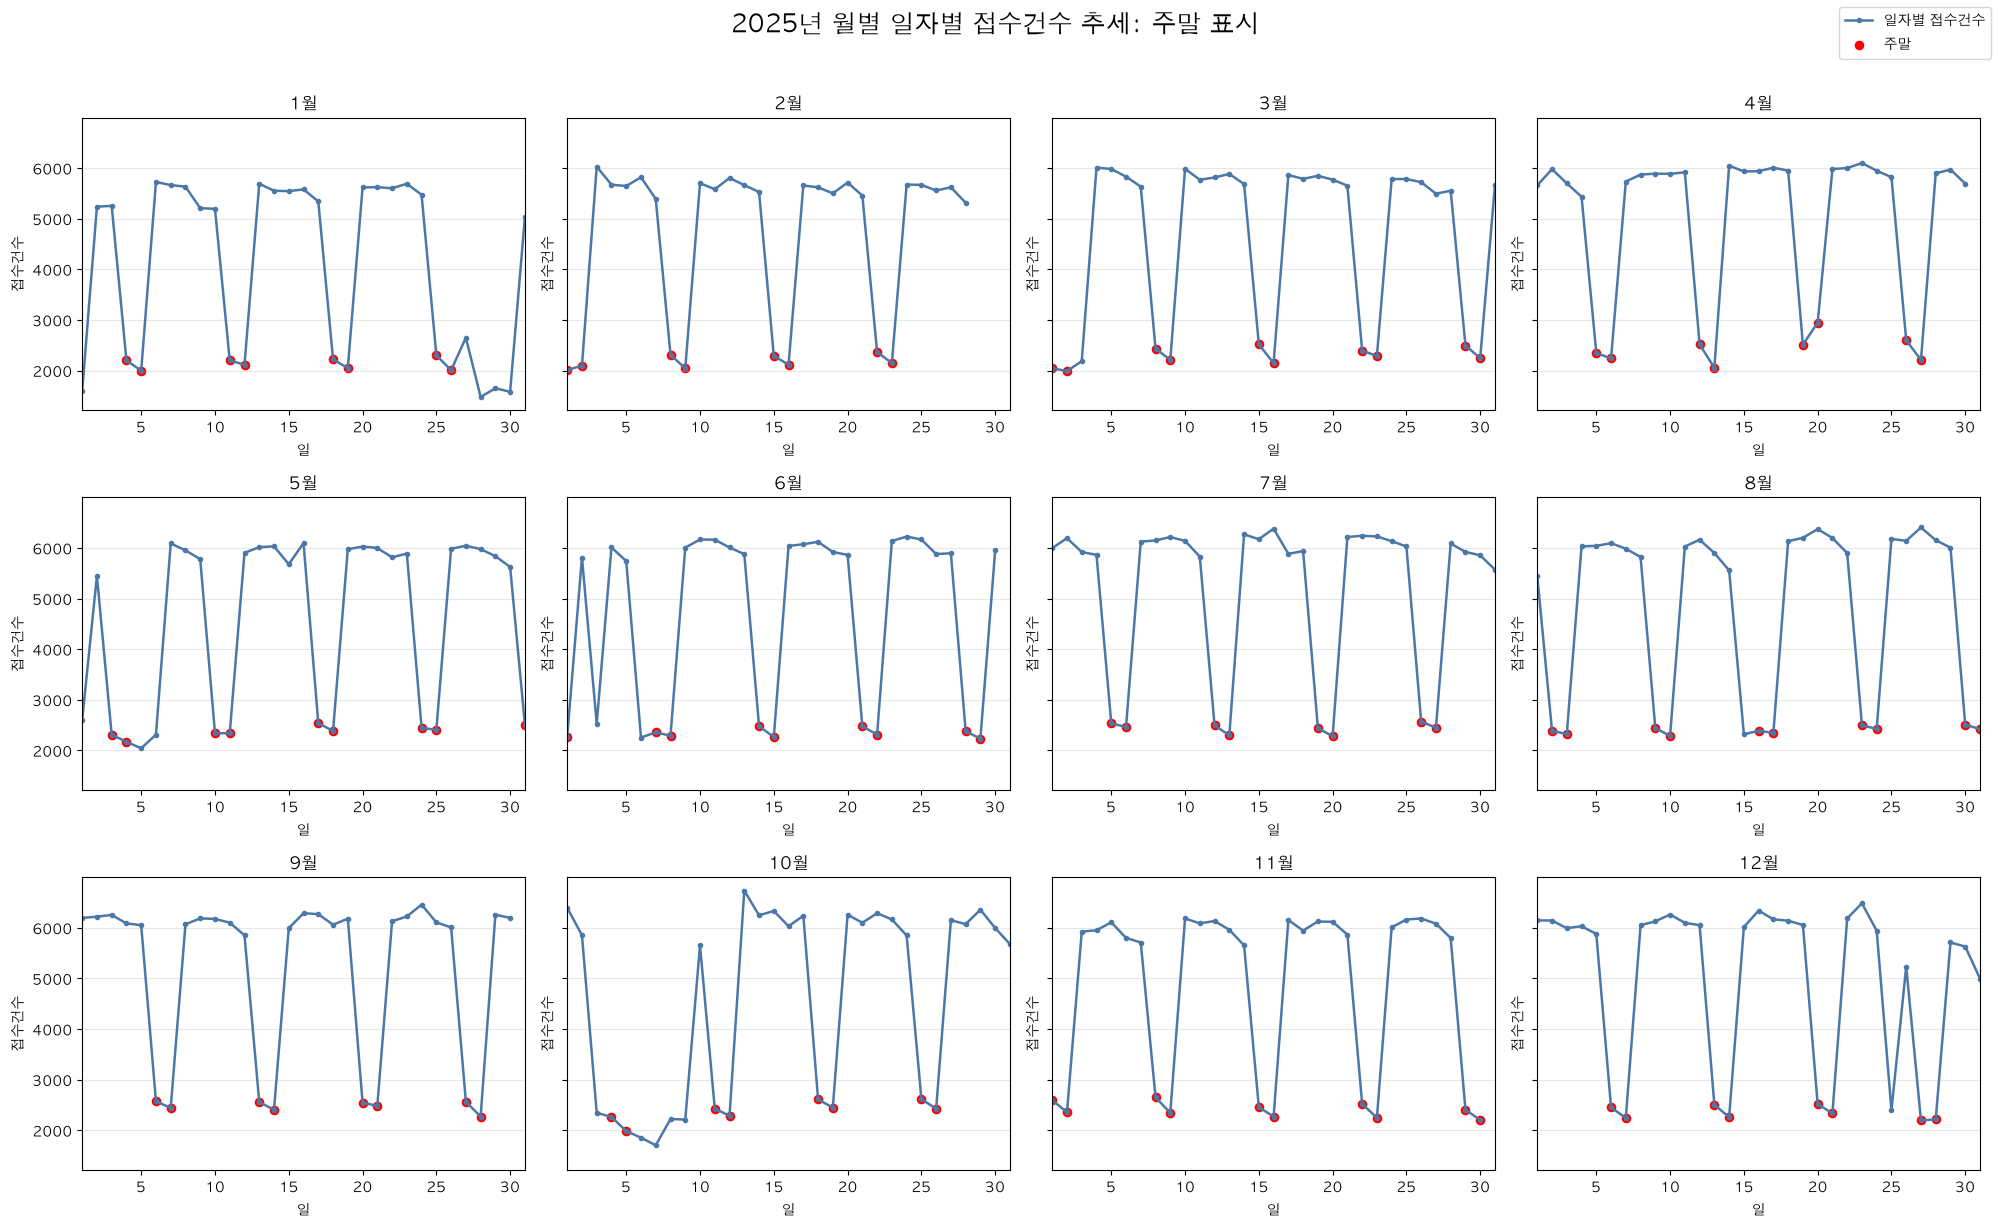

분석 시작일: 2025-01-01
분석 종료일: 2025-12-31
분석 일수: 365일
총 접수건수: 1,722,431건


In [18]:
request_dt = pd.to_datetime(df_request['접수일시'], errors='coerce')

df_request_2025 = df_request[
    (request_dt >= '2025-01-01') &
    (request_dt < '2026-01-01')
].copy()

daily_request_count_2025 = (
    df_request_2025.assign(
        접수일자=pd.to_datetime(df_request_2025['접수일시'], errors='coerce').dt.date
    )
    .dropna(subset=['접수일자'])
    .groupby('접수일자')
    .size()
    .reset_index(name='접수건수')
)

daily_request_count_2025['접수일자'] = pd.to_datetime(daily_request_count_2025['접수일자'])
daily_request_count_2025['접수월'] = daily_request_count_2025['접수일자'].dt.month
daily_request_count_2025['일'] = daily_request_count_2025['접수일자'].dt.day
daily_request_count_2025['요일번호'] = daily_request_count_2025['접수일자'].dt.dayofweek
daily_request_count_2025['주말여부'] = daily_request_count_2025['요일번호'].isin([5, 6])

fig, axes = plt.subplots(3, 4, figsize=(20, 12), sharey=True)
axes = axes.flatten()

for month in range(1, 13):
    ax = axes[month - 1]

    month_data = daily_request_count_2025[
        daily_request_count_2025['접수월'] == month
    ]

    weekend_data = month_data[month_data['주말여부']]

    ax.plot(
        month_data['일'],
        month_data['접수건수'],
        marker='o',
        linewidth=1.8,
        markersize=3,
        color='#4c78a8',
        label='일자별 접수건수'
    )

    ax.scatter(
        weekend_data['일'],
        weekend_data['접수건수'],
        color='red',
        s=35,
        label='주말'
    )

    ax.set_title(f'{month}월')
    ax.set_xlabel('일')
    ax.set_ylabel('접수건수')
    ax.grid(axis='y', alpha=0.3)
    ax.set_xlim(1, 31)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper right')

plt.suptitle('2025년 월별 일자별 접수건수 추세: 주말 표시', fontsize=18, y=1.02)
plt.tight_layout()
plt.show()

print(f"분석 시작일: {daily_request_count_2025['접수일자'].min().date()}")
print(f"분석 종료일: {daily_request_count_2025['접수일자'].max().date()}")
print(f"분석 일수: {daily_request_count_2025['접수일자'].nunique():,}일")
print(f"총 접수건수: {daily_request_count_2025['접수건수'].sum():,}건")


In [15]:
request_dt = pd.to_datetime(df_request['접수일시'], errors='coerce')

daily_request_count = (
    df_request.assign(접수일자=request_dt.dt.date)
    .dropna(subset=['접수일자'])
    .groupby('접수일자')
    .size()
    .reset_index(name='접수건수')
)

daily_request_count['접수일자'] = pd.to_datetime(daily_request_count['접수일자'])

max_request_day = daily_request_count.loc[
    daily_request_count['접수건수'].idxmax()
]

min_request_day = daily_request_count.loc[
    daily_request_count['접수건수'].idxmin()
]

top_request_days = daily_request_count.sort_values(
    '접수건수',
    ascending=False
).head(10)

bottom_request_days = daily_request_count.sort_values(
    '접수건수',
    ascending=True
).head(10)

print('최대 접수일')
display(max_request_day.to_frame().T)

print('최소 접수일')
display(min_request_day.to_frame().T)

print('접수건수 상위 날짜 TOP 10')
display(top_request_days)

print('접수건수 하위 날짜 TOP 10')
display(bottom_request_days)

최대 접수일


,접수일자,접수건수
286,2025-10-13 00:00:00,6736


최소 접수일


,접수일자,접수건수
0,2024-12-31 00:00:00,59


접수건수 상위 날짜 TOP 10


,접수일자,접수건수
286,2025-10-13,6736
357,2025-12-23,6485
267,2025-09-24,6459
239,2025-08-27,6406
274,2025-10-01,6398
197,2025-07-16,6382
232,2025-08-20,6373
302,2025-10-29,6359
350,2025-12-16,6341
288,2025-10-15,6333


접수건수 하위 날짜 TOP 10


,접수일자,접수건수
0,2024-12-31,59
28,2025-01-28,1479
30,2025-01-30,1581
1,2025-01-01,1593
29,2025-01-29,1649
280,2025-10-07,1703
279,2025-10-06,1854
278,2025-10-05,1985
61,2025-03-02,1989
5,2025-01-05,1997


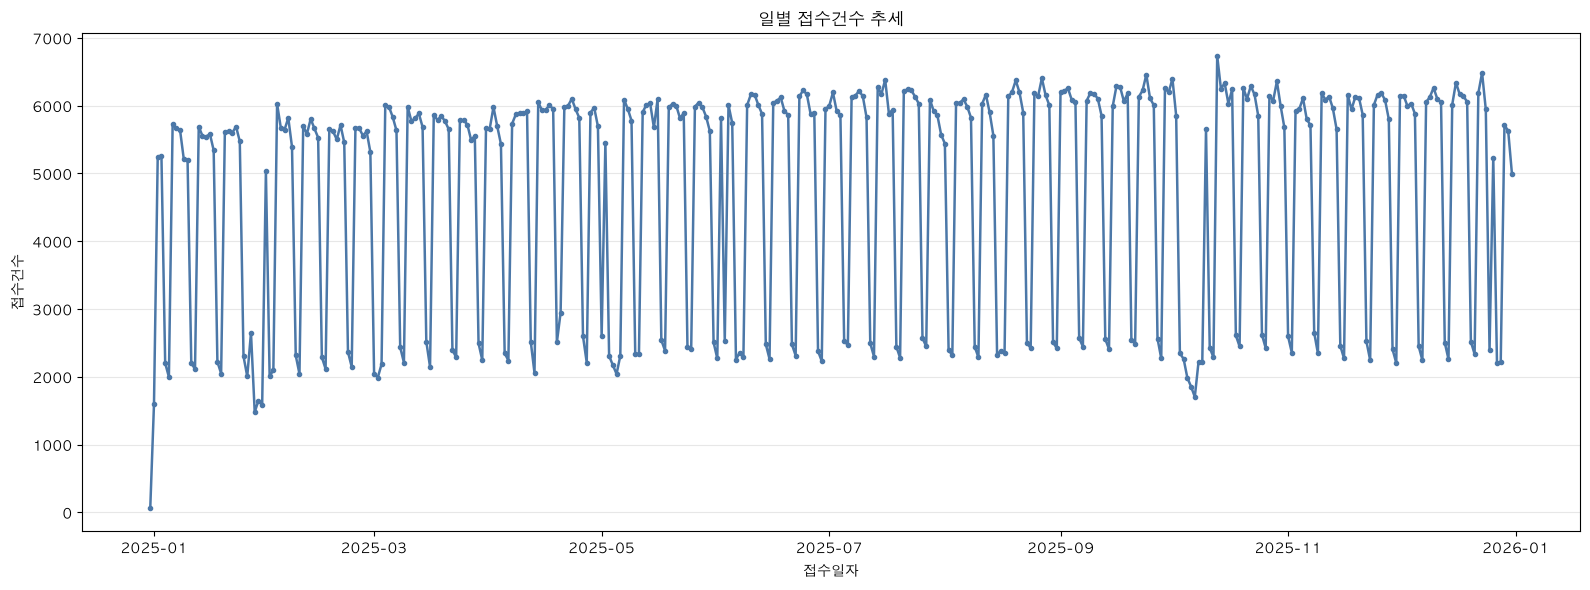

In [19]:
request_dt = pd.to_datetime(df_request['접수일시'], errors='coerce')

daily_request_count = (
    df_request.assign(접수일자=request_dt.dt.date)
    .dropna(subset=['접수일자'])
    .groupby('접수일자')
    .size()
    .reset_index(name='접수건수')
)

daily_request_count['접수일자'] = pd.to_datetime(daily_request_count['접수일자'])

plt.figure(figsize=(16, 6))

plt.plot(
    daily_request_count['접수일자'],
    daily_request_count['접수건수'],
    color='#4c78a8',
    linewidth=1.8,
    marker='o',
    markersize=3
)

plt.title('일별 접수건수 추세')
plt.xlabel('접수일자')
plt.ylabel('접수건수')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### 일자별 접수 추세

In [20]:
request_dt = pd.to_datetime(df_request['접수일시'], errors='coerce')

df_request_2025 = df_request[
    (request_dt >= '2025-01-01') &
    (request_dt < '2026-01-01')
].copy()

daily_request_count = (
    df_request_2025.assign(
        접수일자=pd.to_datetime(df_request_2025['접수일시'], errors='coerce').dt.date
    )
    .dropna(subset=['접수일자'])
    .groupby('접수일자')
    .size()
    .reset_index(name='접수건수')
)

daily_request_count['접수일자'] = pd.to_datetime(daily_request_count['접수일자'])
daily_request_count['접수월'] = daily_request_count['접수일자'].dt.month
daily_request_count['접수월주차'] = (
    daily_request_count['접수일자'].dt.strftime('%Y-%m')
    + '-'
    + (((daily_request_count['접수일자'].dt.day + daily_request_count['접수일자'].dt.to_period('M').dt.to_timestamp().dt.dayofweek - 1) // 7 + 1).astype(str))
    + '주차'
)

daily_request_count.head()

,접수일자,접수건수,접수월,접수월주차
0,2025-01-01,1593,1,2025-01-1주차
1,2025-01-02,5238,1,2025-01-1주차
2,2025-01-03,5255,1,2025-01-1주차
3,2025-01-04,2201,1,2025-01-1주차
4,2025-01-05,1997,1,2025-01-1주차


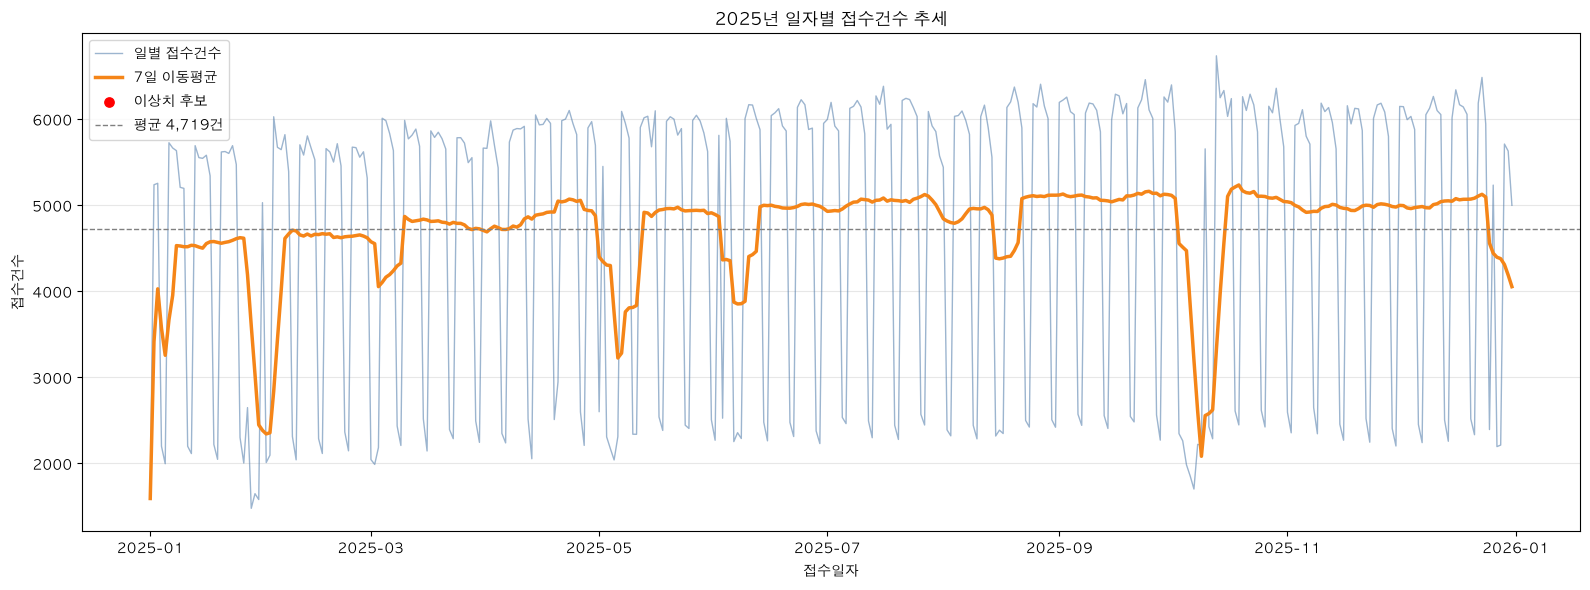

일평균 접수건수: 4,718.99
표준편차: 1,725.80
이상치 후보 날짜 수: 0


In [21]:
request_dt = pd.to_datetime(df_request['접수일시'], errors='coerce')

df_request_2025 = df_request[
    (request_dt >= '2025-01-01') &
    (request_dt < '2026-01-01')
].copy()

daily_request_count = (
    df_request_2025.assign(
        접수일자=pd.to_datetime(df_request_2025['접수일시'], errors='coerce').dt.date
    )
    .dropna(subset=['접수일자'])
    .groupby('접수일자')
    .size()
    .reset_index(name='접수건수')
)

daily_request_count['접수일자'] = pd.to_datetime(daily_request_count['접수일자'])

daily_request_count['7일이동평균'] = (
    daily_request_count['접수건수']
    .rolling(window=7, min_periods=1)
    .mean()
)

mean_count = daily_request_count['접수건수'].mean()
std_count = daily_request_count['접수건수'].std()

daily_request_count['z_score'] = (
    daily_request_count['접수건수'] - mean_count
) / std_count

outlier_dates = daily_request_count[
    daily_request_count['z_score'].abs() >= 3
]

plt.figure(figsize=(16, 6))

plt.plot(
    daily_request_count['접수일자'],
    daily_request_count['접수건수'],
    color='#4c78a8',
    linewidth=1,
    alpha=0.55,
    label='일별 접수건수'
)

plt.plot(
    daily_request_count['접수일자'],
    daily_request_count['7일이동평균'],
    color='#f58518',
    linewidth=2.5,
    label='7일 이동평균'
)

plt.scatter(
    outlier_dates['접수일자'],
    outlier_dates['접수건수'],
    color='red',
    s=45,
    label='이상치 후보'
)

plt.axhline(
    mean_count,
    color='gray',
    linestyle='--',
    linewidth=1,
    label=f'평균 {mean_count:,.0f}건'
)

plt.title('2025년 일자별 접수건수 추세')
plt.xlabel('접수일자')
plt.ylabel('접수건수')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print(f'일평균 접수건수: {mean_count:,.2f}')
print(f'표준편차: {std_count:,.2f}')
print(f'이상치 후보 날짜 수: {len(outlier_dates):,}')

### 지역별 접수 수요

`출발구`, `목적구`, `출발구-목적구 조합` 기준으로 접수건수를 집계해 지역별 요청 집중도를 확인한다.



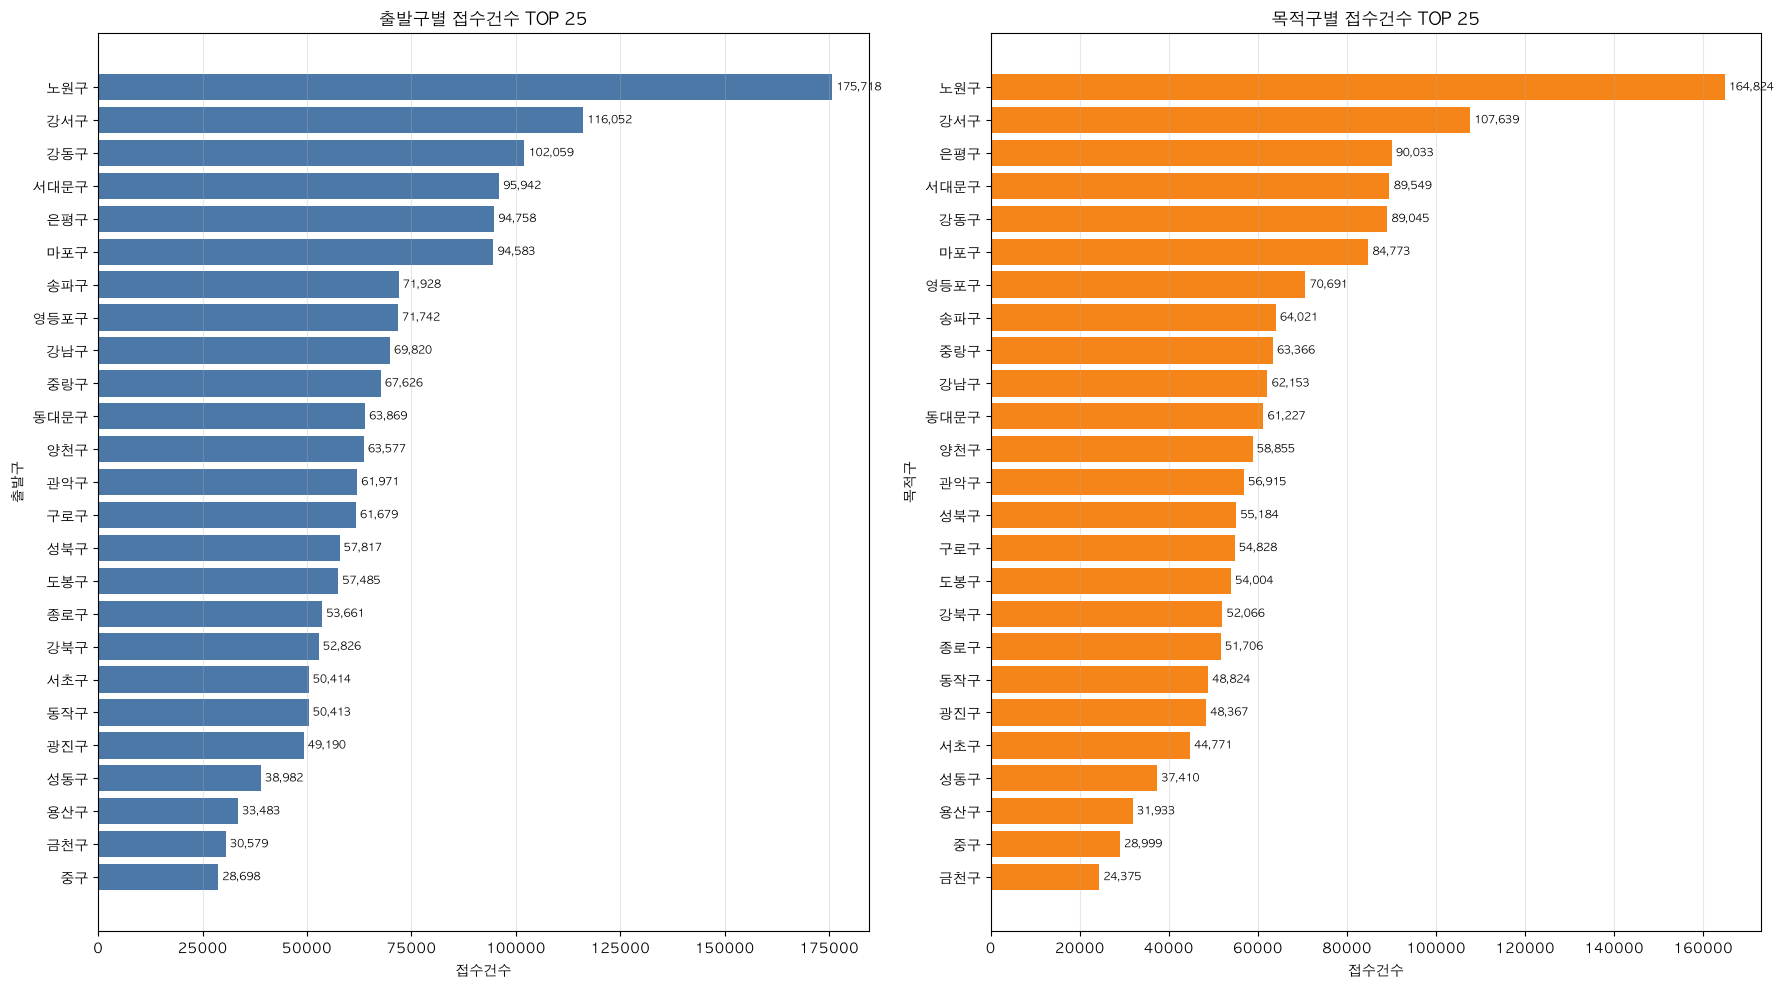

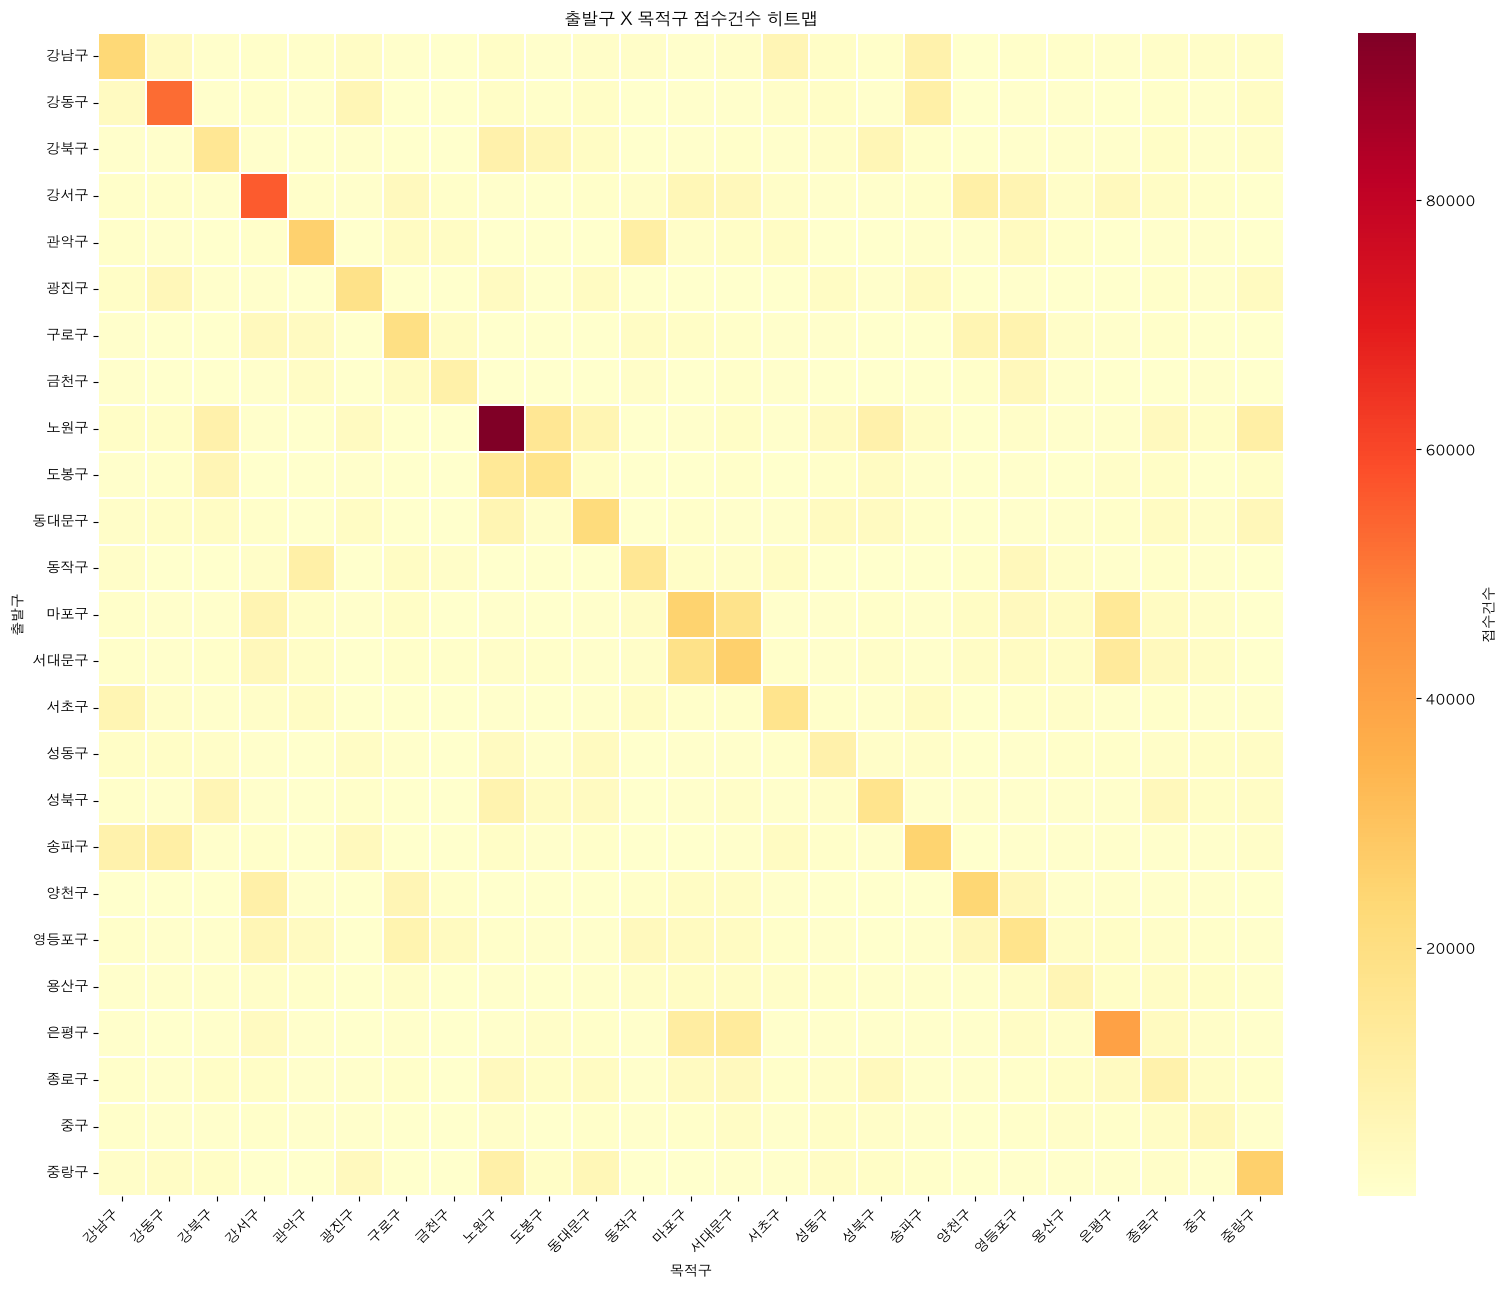

출발구별 접수건수 TOP 10


,출발구,접수건수
0,노원구,175718
1,강서구,116052
2,강동구,102059
3,서대문구,95942
4,은평구,94758
5,마포구,94583
6,송파구,71928
7,영등포구,71742
8,강남구,69820
9,중랑구,67626


목적구별 접수건수 TOP 10


,목적구,접수건수
0,노원구,164824
1,강서구,107639
2,은평구,90033
3,서대문구,89549
4,강동구,89045
5,마포구,84773
6,영등포구,70691
7,송파구,64021
8,중랑구,63366
9,강남구,62153


출발구 X 목적구 접수건수 TOP 20


,출발구,목적구,접수건수
0,노원구,노원구,93371
1,강서구,강서구,55994
2,강동구,강동구,52591
3,은평구,은평구,40205
4,중랑구,중랑구,26151
5,서대문구,서대문구,26081
6,관악구,관악구,25878
7,마포구,마포구,25480
8,송파구,송파구,25169
9,양천구,양천구,23856


In [22]:
# REGION_REQUEST_DEMAND_ANALYSIS_CELL
# 지역별 접수 수요 분석: 출발구, 목적구, 출발구 X 목적구 조합
if 'df_request' not in globals():
    df_request = pd.read_csv(
        'data/서울시설공단_장애인콜택시 접수일시_월주차_파생컬럼_20251231.csv'
    )

서울_25개구 = [
    '강남구', '강동구', '강북구', '강서구', '관악구',
    '광진구', '구로구', '금천구', '노원구', '도봉구',
    '동대문구', '동작구', '마포구', '서대문구', '서초구',
    '성동구', '성북구', '송파구', '양천구', '영등포구',
    '용산구', '은평구', '종로구', '중구', '중랑구',
]

출발구별_접수건수 = (
    df_request
    .dropna(subset=['출발구'])
    .groupby('출발구')
    .size()
    .reset_index(name='접수건수')
    .sort_values('접수건수', ascending=False)
    .reset_index(drop=True)
)

목적구별_접수건수 = (
    df_request
    .dropna(subset=['목적구'])
    .groupby('목적구')
    .size()
    .reset_index(name='접수건수')
    .sort_values('접수건수', ascending=False)
    .reset_index(drop=True)
)

출발구_top25 = 출발구별_접수건수.head(25).sort_values('접수건수')
목적구_top25 = 목적구별_접수건수.head(25).sort_values('접수건수')

fig, (ax_start, ax_dest) = plt.subplots(1, 2, figsize=(18, 10))

ax_start.barh(출발구_top25['출발구'], 출발구_top25['접수건수'], color='#4c78a8')
ax_start.set_title('출발구별 접수건수 TOP 25')
ax_start.set_xlabel('접수건수')
ax_start.set_ylabel('출발구')
ax_start.grid(axis='x', alpha=0.3)
for index, value in enumerate(출발구_top25['접수건수']):
    ax_start.text(value, index, f' {value:,.0f}', va='center', fontsize=8)

ax_dest.barh(목적구_top25['목적구'], 목적구_top25['접수건수'], color='#f58518')
ax_dest.set_title('목적구별 접수건수 TOP 25')
ax_dest.set_xlabel('접수건수')
ax_dest.set_ylabel('목적구')
ax_dest.grid(axis='x', alpha=0.3)
for index, value in enumerate(목적구_top25['접수건수']):
    ax_dest.text(value, index, f' {value:,.0f}', va='center', fontsize=8)

plt.tight_layout()
plt.show()

출발구_목적구_접수건수 = (
    df_request
    .dropna(subset=['출발구', '목적구'])
    .groupby(['출발구', '목적구'])
    .size()
    .reset_index(name='접수건수')
    .sort_values('접수건수', ascending=False)
    .reset_index(drop=True)
)

출발구_목적구_피벗 = (
    출발구_목적구_접수건수
    .pivot_table(
        index='출발구',
        columns='목적구',
        values='접수건수',
        aggfunc='sum',
        fill_value=0
    )
    .reindex(index=서울_25개구, columns=서울_25개구, fill_value=0)
)

plt.figure(figsize=(16, 13))
sns.heatmap(
    출발구_목적구_피벗,
    cmap='YlOrRd',
    linewidths=0.3,
    cbar_kws={'label': '접수건수'}
)
plt.title('출발구 X 목적구 접수건수 히트맵')
plt.xlabel('목적구')
plt.ylabel('출발구')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

print('출발구별 접수건수 TOP 10')
display(출발구별_접수건수.head(10))

print('목적구별 접수건수 TOP 10')
display(목적구별_접수건수.head(10))

print('출발구 X 목적구 접수건수 TOP 20')
display(출발구_목적구_접수건수.head(20))

